# StyleCLIP

Редактирование изображений -- очень важная и интересная задача в мире генеративных моделей. В этом ноутбуке мы с вами попробуем решить эту задачу на основе работы [StyleCLIP](https://arxiv.org/abs/2103.17249).

Данный метод позволяет редактировать изображения, сгенерированные [StyleGAN2](https://github.com/rosinality/stylegan2-pytorch), используя текстовые описания. Например, вы можете взять фотографию человека и с помощью текстовой подсказки "сделать волосы кудрявыми" изменить прическу на фотографии. Основная идея данной работы в том, чтобы "подвинуть" изначальный латент так, чтобы сгенерированное из него изображение лучше соответствовало предложенному промпту. Авторы предлагают два основных подхода:

- Оптимизация латентного вектора на основе CLIP Loss

- Обучение специального Mapper для сдвига

Более подробно про эти два подхода можно почитать в самой стате [StyleCLIP](https://arxiv.org/abs/2103.17249).

Мы с вами рассмотрим только одну часть предложенного метода, а именно оптимизацию для редактирования. Как уже было сказано, StyleCLIP оптимизирует латентный вектор [StyleGAN2](https://arxiv.org/abs/1912.04958) для более точного соотвествия заданному промпту.

Идея StyleCLIP с оптимизацией отображена на изображении ниже.




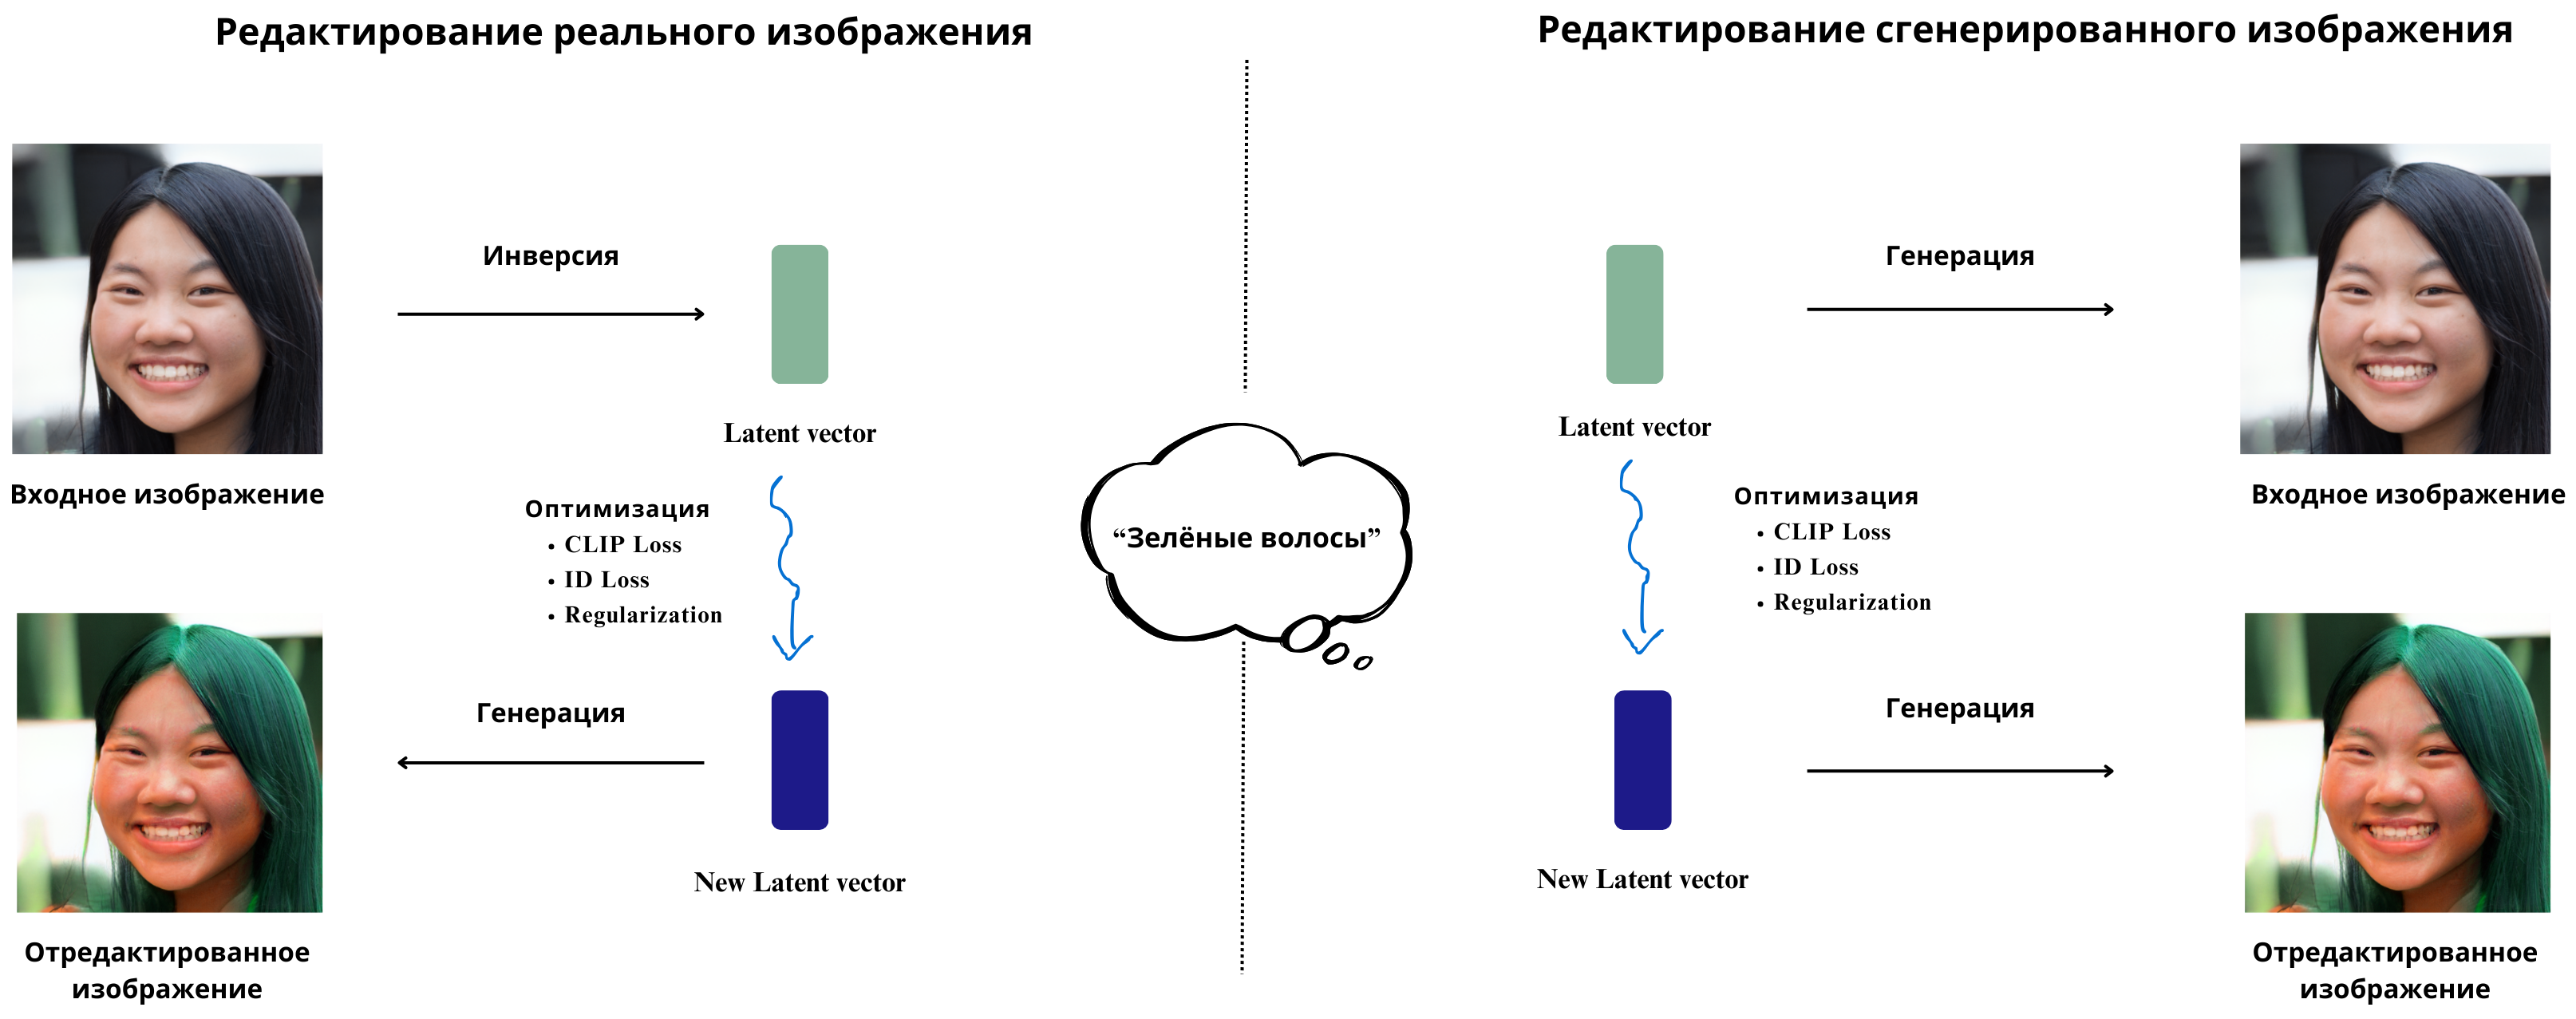

Наш план будет состоять в следующем:

1. Подготовка всех моделей для оптимизации

2. Реализация всех необходимых функций потерь:

  - CLIP Loss (1 балла)
  - ID Loss (1 балла)

3. Подготовка кода оптимизации (2 балла)

4. Выводы из полученных результатов (1 балл)

Давайте же попробуем написать код для этой оптимизации!

## Установка необходимых библиотек и подготовка окружения
Начнем с установки необходимых библиотек и клонирования репозитория StyleCLIP, чтобы использовать его методы.

In [1]:
# Установка необходимых библиотек

# Установка зависимостей
!pip install ftfy regex tqdm
!pip install git+https://github.com/openai/CLIP.git
# Установка дополнительных библиотек
!pip install Ninja

# Импорт нужных библиотек
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torchvision.utils import save_image
import clip
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt


  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-jod70qup
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-jod70qup
  Resolved https://github.com/openai/CLIP.git to commit d05afc436d78f1c48dc0dbf8e5980a9d471f35f6
  Preparing metadata (setup.py) ... done


In [2]:
# Клонирование репозитория StyleGAN2
!git clone https://github.com/rosinality/stylegan2-pytorch.git

fatal: destination path 'stylegan2-pytorch' already exists and is not an empty directory.


In [3]:
cd stylegan2-pytorch/

/content/stylegan2-pytorch


In [4]:
# Будем работать с конкретным сидом
torch.manual_seed(42)

## Основная идея статьи


Как уже было сказано, мы хотим редактировать изображение с помощью текста. Для этого будем использовать [CLIP](https://paperswithcode.com/method/clip) модель для некоторого гайданса в процессе оптимизации.

Задачу мы хотим построить следующим образом: имея исходный латентный вектор $w \in W$ мы хотим оптимизировать его под текстовый запрос $t$. Давайте подгрузм нашу модель и сгенерируем картинку для дальнейшей оптимизации.

Для работы со StyleGAN-2 нам для начала нужно скачать модель. Для скачивания мы используем следующий код:

In [5]:
from pydrive2.auth import GoogleAuth
from pydrive2.drive import GoogleDrive
from google.colab import auth
from oauth2client.client import GoogleCredentials

# Authenticate and create the PyDrive client.
auth.authenticate_user()
gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()
drive = GoogleDrive(gauth)

# downloads StyleGAN's weights and facial recognition network weights
ids = ['1EM87UquaoQmk17Q8d5kYIAHqu0dkYqdT', '1N0MZSqPRJpLfP4mFQCS14ikrVSe8vQlL']
for file_id in ids:
  downloaded = drive.CreateFile({'id':file_id})
  downloaded.FetchMetadata(fetch_all=True)
  downloaded.GetContentFile(downloaded.metadata['title'])

In [6]:
# Зададим девайс: cuda или cpu
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Зададим сид
seed = 3456
torch.manual_seed(seed)

# Загрузка модели генератора StyleGAN2
from model import Generator
latent_dim = 512
generator = Generator(size=1024, style_dim=latent_dim, n_mlp=8).to(device)
state_dict = torch.load('/content/stylegan2-pytorch/stylegan2-ffhq-config-f.pt', map_location=device)
generator.load_state_dict(state_dict['g_ema'])
generator.eval()

print("Генератор StyleGAN2 загружены.")


Генератор StyleGAN2 загружены.


### Функция для генерации изображения из латентного вектора
Эта функция генерирует изображение из латентного вектора $z \in Z$ ($w \in W$), что нам пригодится для визуализации процесса редактирования.

/content/stylegan2-pytorch/op/conv2d_gradfix.py:88: UserWarning: conv2d_gradfix not supported on PyTorch 2.11.0+cu128. Falling back to torch.nn.functional.conv2d().
  warnings.warn(


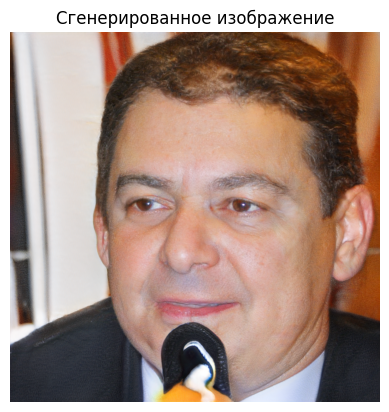

In [7]:
# Сгенерируем изображение
latent_z = torch.randn(10000, 512, device=device) # Z noise
latent_z_generated = latent_z.mean(0, keepdim=True)

with torch.no_grad():
  target_img, _ = generator([latent_z_generated], input_is_latent=False)
  plt.imshow((target_img.clip(-1,1).cpu().detach()[0].permute(1, 2, 0) + 1) / 2)
  plt.title(f"Сгенерированное изображение")
  plt.axis('off')
  plt.show()

# Визуализируйте изначальную картинку
# YOUR CODE IS HERE

## Задача оптимизации

Теперь давайте подронее сформулируем задачу оптимизации.

Нам необходимо следующее:

- Отредактированное изображение соответствует текстовому запросу

- Сохраняет identity изначального человека.

Авторы предлагают следующий лосс для оптимизации:

$$\arg \min_{w \in W} D_{\text{CLIP}}(G(w), t) + \lambda_2 \|w - w_s\|_2 + \lambda_{\text{ID}} L_{\text{ID}}(w)
$$

Давайте разберёмся с каждой частью подробнее.

### CLIP loss

Начнём мы с CLIP loss.

 $D_{\text{CLIP}}$ — косинусное расстояние между эмбеддингами [CLIP](https://habr.com/ru/articles/539312/) для двух аргументов.

$$D_{\text{CLIP}}(G(w), t) = 1 - \frac{\langle E_{\text{CLIP}}(G(w)) \cdot E_{\text{CLIP}}(t) \rangle }{\|E_{\text{CLIP}}(G(w))\| \cdot \|E_{\text{CLIP}}(t)\|}$$


In [8]:
import torch
import clip


class CLIPLoss(torch.nn.Module):
    """
    Этот класс определяет пользовательскую функцию потерь на основе CLIP (Contrastive Language–Image Pre-training).
    Он измеряет сходство между изображением и текстовым описанием.
    """

    def __init__(self, stylegan_size=1024):
        """
        Инициализирует класс CLIPLoss.

        Args:
            opts: Объект, содержащий различные параметры, включая размер изображения StyleGAN.
        """
        super(CLIPLoss, self).__init__()
        # Загружаем предварительно обученную модель CLIP и функцию предварительной обработки
        self.model, self.preprocess = clip.load("ViT-B/32", device="cuda")

        self.upsample = torch.nn.Upsample(scale_factor=7)
        self.avg_pool = torch.nn.AvgPool2d(kernel_size=stylegan_size // 32)
        self.cos = nn.CosineSimilarity(dim=1, eps=1e-6)

    def forward(self, image, text):
        """
        Вычисляет потери CLIP между изображением и текстом.

        Args:
            image: Входной тензор изображения.
            text: Тензор текстового описания.

        Returns:
            Значение потерь CLIP.
        """
        # Меняем размерность изображения для получения нужного разрешения для CLIP
        image = self.avg_pool(self.upsample(image))
        if isinstance(text, str):
            text = [text]

        if isinstance(text, list):
            text = clip.tokenize(text).to(self.device)

        image_features = self.model.encode_image(image)
        text_features = self.model.encode_text(text)

        image_features = image_features / image_features.norm(dim=1, keepdim=True)
        text_features = text_features / text_features.norm(dim=1, keepdim=True)

        similarity = self.cos(image_features, text_features)

        loss = 1 - similarity
        
        return loss.mean()

In [9]:
clip_loss = CLIPLoss()

### ID loss

Для сохранения identity человека использует специально предобученную модель [ArcFace](https://arxiv.org/abs/1801.07698), которая по фотографии вычисляет некоторые характерные для человека embedding вектора. Затем нам необходимо посчитать косинусное расстояние между ожидаемым embedding вектором и тем, что получается в процессе оптимизации:

$$ L_{\text{ID}}(w) = 1 - \langle R(G(w_s)), R(G(w)) \rangle $$

Обратите внимание, что здесь не используется дополнительная нормировка


Давайте подгрузим нашу модель и реализуем желаемую функцию потерь.


### Подгрузка модели

Далее у нас будет подгрузка самой модели, позаимствованная из репозитория [StyleCLIP](https://github.com/orpatashnik/StyleCLIP/blob/main/models/facial_recognition/helpers.py). Вы можете более подробно ознакомиться с кодом этой модели ниже, но мы не будем заострять на ней внимание.


In [10]:
from torch.nn import Linear, Conv2d, BatchNorm1d, BatchNorm2d, PReLU, Dropout, Sequential, Module

"""
Modified Backbone implementation from [TreB1eN](https://github.com/TreB1eN/InsightFace_Pytorch)
"""
from collections import namedtuple
import torch
from torch.nn import Conv2d, BatchNorm2d, PReLU, ReLU, Sigmoid, MaxPool2d, AdaptiveAvgPool2d, Sequential, Module

"""
ArcFace implementation from [TreB1eN](https://github.com/TreB1eN/InsightFace_Pytorch)
"""


class Flatten(Module):
	def forward(self, input):
		return input.view(input.size(0), -1)


def l2_norm(input, axis=1):
	norm = torch.norm(input, 2, axis, True)
	output = torch.div(input, norm)
	return output


class Bottleneck(namedtuple('Block', ['in_channel', 'depth', 'stride'])):
	""" A named tuple describing a ResNet block. """


def get_block(in_channel, depth, num_units, stride=2):
	return [Bottleneck(in_channel, depth, stride)] + [Bottleneck(depth, depth, 1) for i in range(num_units - 1)]


def get_blocks(num_layers):
	if num_layers == 50:
		blocks = [
			get_block(in_channel=64, depth=64, num_units=3),
			get_block(in_channel=64, depth=128, num_units=4),
			get_block(in_channel=128, depth=256, num_units=14),
			get_block(in_channel=256, depth=512, num_units=3)
		]
	elif num_layers == 100:
		blocks = [
			get_block(in_channel=64, depth=64, num_units=3),
			get_block(in_channel=64, depth=128, num_units=13),
			get_block(in_channel=128, depth=256, num_units=30),
			get_block(in_channel=256, depth=512, num_units=3)
		]
	elif num_layers == 152:
		blocks = [
			get_block(in_channel=64, depth=64, num_units=3),
			get_block(in_channel=64, depth=128, num_units=8),
			get_block(in_channel=128, depth=256, num_units=36),
			get_block(in_channel=256, depth=512, num_units=3)
		]
	else:
		raise ValueError("Invalid number of layers: {}. Must be one of [50, 100, 152]".format(num_layers))
	return blocks


class SEModule(Module):
	def __init__(self, channels, reduction):
		super(SEModule, self).__init__()
		self.avg_pool = AdaptiveAvgPool2d(1)
		self.fc1 = Conv2d(channels, channels // reduction, kernel_size=1, padding=0, bias=False)
		self.relu = ReLU(inplace=True)
		self.fc2 = Conv2d(channels // reduction, channels, kernel_size=1, padding=0, bias=False)
		self.sigmoid = Sigmoid()

	def forward(self, x):
		module_input = x
		x = self.avg_pool(x)
		x = self.fc1(x)
		x = self.relu(x)
		x = self.fc2(x)
		x = self.sigmoid(x)
		return module_input * x


class bottleneck_IR(Module):
	def __init__(self, in_channel, depth, stride):
		super(bottleneck_IR, self).__init__()
		if in_channel == depth:
			self.shortcut_layer = MaxPool2d(1, stride)
		else:
			self.shortcut_layer = Sequential(
				Conv2d(in_channel, depth, (1, 1), stride, bias=False),
				BatchNorm2d(depth)
			)
		self.res_layer = Sequential(
			BatchNorm2d(in_channel),
			Conv2d(in_channel, depth, (3, 3), (1, 1), 1, bias=False), PReLU(depth),
			Conv2d(depth, depth, (3, 3), stride, 1, bias=False), BatchNorm2d(depth)
		)

	def forward(self, x):
		shortcut = self.shortcut_layer(x)
		res = self.res_layer(x)
		return res + shortcut


class bottleneck_IR_SE(Module):
	def __init__(self, in_channel, depth, stride):
		super(bottleneck_IR_SE, self).__init__()
		if in_channel == depth:
			self.shortcut_layer = MaxPool2d(1, stride)
		else:
			self.shortcut_layer = Sequential(
				Conv2d(in_channel, depth, (1, 1), stride, bias=False),
				BatchNorm2d(depth)
			)
		self.res_layer = Sequential(
			BatchNorm2d(in_channel),
			Conv2d(in_channel, depth, (3, 3), (1, 1), 1, bias=False),
			PReLU(depth),
			Conv2d(depth, depth, (3, 3), stride, 1, bias=False),
			BatchNorm2d(depth),
			SEModule(depth, 16)
		)

	def forward(self, x):
		shortcut = self.shortcut_layer(x)
		res = self.res_layer(x)
		return res + shortcut


class Backbone(Module):
	def __init__(self, input_size, num_layers, mode='ir', drop_ratio=0.4, affine=True):
		super(Backbone, self).__init__()
		assert input_size in [112, 224], "input_size should be 112 or 224"
		assert num_layers in [50, 100, 152], "num_layers should be 50, 100 or 152"
		assert mode in ['ir', 'ir_se'], "mode should be ir or ir_se"
		blocks = get_blocks(num_layers)
		if mode == 'ir':
			unit_module = bottleneck_IR
		elif mode == 'ir_se':
			unit_module = bottleneck_IR_SE
		self.input_layer = Sequential(Conv2d(3, 64, (3, 3), 1, 1, bias=False),
									  BatchNorm2d(64),
									  PReLU(64))
		if input_size == 112:
			self.output_layer = Sequential(BatchNorm2d(512),
			                               Dropout(drop_ratio),
			                               Flatten(),
			                               Linear(512 * 7 * 7, 512),
			                               BatchNorm1d(512, affine=affine))
		else:
			self.output_layer = Sequential(BatchNorm2d(512),
			                               Dropout(drop_ratio),
			                               Flatten(),
			                               Linear(512 * 14 * 14, 512),
			                               BatchNorm1d(512, affine=affine))

		modules = []
		for block in blocks:
			for bottleneck in block:
				modules.append(unit_module(bottleneck.in_channel,
										   bottleneck.depth,
										   bottleneck.stride))
		self.body = Sequential(*modules)

	def forward(self, x):
		x = self.input_layer(x)
		x = self.body(x)
		x = self.output_layer(x)
		return l2_norm(x)


def IR_50(input_size):
	"""Constructs a ir-50 model."""
	model = Backbone(input_size, num_layers=50, mode='ir', drop_ratio=0.4, affine=False)
	return model


def IR_101(input_size):
	"""Constructs a ir-101 model."""
	model = Backbone(input_size, num_layers=100, mode='ir', drop_ratio=0.4, affine=False)
	return model


def IR_152(input_size):
	"""Constructs a ir-152 model."""
	model = Backbone(input_size, num_layers=152, mode='ir', drop_ratio=0.4, affine=False)
	return model


def IR_SE_50(input_size):
	"""Constructs a ir_se-50 model."""
	model = Backbone(input_size, num_layers=50, mode='ir_se', drop_ratio=0.4, affine=False)
	return model


def IR_SE_101(input_size):
	"""Constructs a ir_se-101 model."""
	model = Backbone(input_size, num_layers=100, mode='ir_se', drop_ratio=0.4, affine=False)
	return model


def IR_SE_152(input_size):
	"""Constructs a ir_se-152 model."""
	model = Backbone(input_size, num_layers=152, mode='ir_se', drop_ratio=0.4, affine=False)
	return model

### ID loss

Теперь непосредственно реализуем нашу функцию потерь.

In [11]:
import torch
from torch import nn


class IDLoss(nn.Module):
    def __init__(self, model_weights, device='cuda'):
        super(IDLoss, self).__init__()
        print('Loading ResNet ArcFace')
        # Загружаем предобученную модель ResNet ArcFace для извлечения признаков лица.
        # input_size: размер входного изображения (112x112).
        self.facenet = Backbone(input_size=112, num_layers=50, drop_ratio=0.6, mode='ir_se')
        # Загружаем веса предобученной модели
        self.facenet.load_state_dict(torch.load(model_weights))
        self.pool = torch.nn.AdaptiveAvgPool2d((256, 256))
        self.face_pool = torch.nn.AdaptiveAvgPool2d((112, 112))
        self.facenet.eval()
        # Перемещаем модель ArcFace на GPU, если доступен.
        self.facenet.to(device)


    def extract_feats(self, x):
        # Функция для извлечения эмбеддингов лица из изображения x.
        # Если размер изображения не 256x256, изменяем его с помощью пулинга.
        if x.shape[2] != 256:
            x = self.pool(x)
        # Обрезаем центральную область изображения (35:223, 32:220), содержащую лицо.
        x = x[:, :, 35:223, 32:220]
        # Изменяем размер обрезанной области до 112x112 с помощью пулинга.
        x = self.face_pool(x)
        # Извлекаем эмбеддинги лица с помощью модели ArcFace.
        x_feats = self.facenet(x)
        # Возвращаем извлеченные эмбеддинги.
        return x_feats

    def forward(self, y_hat, y):
        # Функция для вычисления ID Loss.
        # y_hat: отредактированное изображение.
        # y: исходное изображение.
        n_samples = y.shape[0]
        # Извлекаем признаки лица из исходного изображения.
        # YOUR CODE IS HERE
        y_feats = self.extract_feats(y).detach()

        # Извлекаем признаки лица из отредактированного изображения.
        # YOUR CODE IS HERE
        y_hat_feats = self.extract_feats(y_hat)

        # Не забудьте сделать detach()!
        # YOUR CODE IS HERE
        loss = 0.0


        # Считаем наш лосс
        for i in range(n_samples):
            # Считаем косинусное расстояние между признаками исходного и
            # оптимизируемого изображения
            # YOUR CODE IS HERE
            similarity = torch.dot(y_hat_feats[i], y_feats[i])
            loss += 1 - similarity

        loss = loss / n_samples



        return loss

In [12]:
# Загрузим нашу модель ArcFace
model_path = "/content/stylegan2-pytorch/model_ir_se50.pth"
id_loss = IDLoss(model_path, device)

Loading ResNet ArcFace


## Инициализация латентного вектора и текстовой подсказки
Определим латентный вектор
𝑊
W для исходного изображения и преобразуем текстовую подсказку в вектор с помощью CLIP, что будет служить нашей целью для редактирования.

## Оптимизация для редактирования изображения
Реализуем оптимизацию, используя Adam. На каждом шаге обновляется латентный вектор $w \in W$ для минимизации потерь CLIP, пока результат не будет похож на текстовую подсказку.

Основной псевдокод оптимизации представлен ниже:

```python

for step in range(num_steps):  # <----------- итерируемся по датасету несколько раз
    torch.cuda.empty_cache() # <------------- очищаем кэш модели
    optimizer.zero_grad()  # <------------- обуляем градиенты модели
    image, _ = generator([latent], input_is_latent=True, randomize_noise=False)  # <------------- получаем картинку из StyleGAN-2
    loss = clip_loss + l2_lambda * l2_loss + id_lambda * id_loss
    loss.backward()  # <------------------- считаем градиенты
    optimizer.step()  # <------------------ делаем шаг градиентного спуска
    if convergence:  # <------------------- в случае сходимости выходим из цикла
        break
```

Где полная функция потерь считается по формуле:
$$\arg \min_{w \in W} D_{\text{CLIP}}(G(w), t) + \lambda_2 \|w - w_s\|_2 + \lambda_{\text{ID}} L_{\text{ID}}(w)
$$

Дополнительно сохраните значения лосс функций для дальнейшей визуализации.


In [13]:
# Подготавливаем текстовый промпт для оптимизации, который будет направлять изменение изображения.
prompt = "a person with black skin"

# Токенизируем промпт с помощью CLIP tokenizer и перемещаем на устройство (CPU или GPU).
# clip.tokenize: функция из библиотеки CLIP для токенизации текста.
text_inputs = torch.cat([clip.tokenize(prompt)]).to(device)

In [14]:
# Подготовим папку для сохранения результатов
import os
save_dir = "results"
os.makedirs(save_dir, exist_ok=True)

Работать предлагаем в пространстве $W$, давайте преобразуем наш вектор в styleSpace

In [15]:
# Получаем w-вектор из z-вектора с помощью mapping network генератора.
with torch.no_grad():
  latent_w = generator.style(latent_z_generated)

latent = latent_w.detach().clone()
latent.requires_grad = True

In [16]:
%matplotlib inline

In [17]:
import math

def noise_regularize(noises):
    """
    Функция для регуляризации шума.
    Вычисляет лосс на основе шума, чтобы уменьшить его влияние на генерацию.

    Параметры:
    noises (list): Список тензоров шума.

    Возвращает:
    loss (float): Общая потеря, связанная с шумом.
    """
    loss = 0  # Инициализация потерь

    for noise in noises:  # Проход по каждому шуму в списке
        size = noise.shape[2]

        while True:  # Цикл для уменьшения размера шума
            # Вычисление лосса на основе свертки шума с его сдвинутой версией
            loss = (
                loss
                + (noise * torch.roll(noise, shifts=1, dims=3)).mean().pow(2)  # Сдвиг по ширине
                + (noise * torch.roll(noise, shifts=1, dims=2)).mean().pow(2)  # Сдвиг по высоте
            )

            if size <= 8:
                break

            # Уменьшение размера шума вдвое
            noise = noise.reshape([-1, 1, size // 2, 2, size // 2, 2])
            noise = noise.mean([3, 5])
            size //= 2

    return loss


def noise_normalize_(noises):
    """
    Нормализация шума.
    Приводит шум к нулевому среднему и единичной дисперсии.

    Параметры:
    noises (list): Список тензоров шума.
    """
    for noise in noises:
        mean = noise.mean()  # Вычисление среднего значения
        std = noise.std()  # Вычисление стандартного отклонения

        # Нормализация: вычитание среднего и деление на стандартное отклонение
        noise.data.add_(-mean).div_(std)


def latent_noise(latent, strength):
    """
    Добавление шума к латентному вектору.
    Генерирует случайный шум и добавляет его к латентному вектору.

    Параметры:
    latent (Tensor): Латентный вектор.
    strength (float): Сила добавляемого шума.

    Возвращает:
    Tensor: Латентный вектор с добавленным шумом.
    """
    noise = torch.randn_like(latent) * strength

    return latent + noise


def get_lr(t, initial_lr, rampdown=0.25, rampup=0.05):
    lr_ramp = min(1, (1 - t) / rampdown)
    lr_ramp = 0.5 - 0.5 * math.cos(lr_ramp * math.pi)
    lr_ramp = lr_ramp * min(1, t / rampup)

    return initial_lr * lr_ramp

In [18]:
from skimage.metrics import structural_similarity as compare_ssim

In [19]:
!cat lpips/__init__.py


from __future__ import absolute_import
from __future__ import division
from __future__ import print_function

import numpy as np
from skimage.metrics import structural_similarity as compare_ssim
import torch
from torch.autograd import Variable

from lpips import dist_model

class PerceptualLoss(torch.nn.Module):
    def __init__(self, model='net-lin', net='alex', colorspace='rgb', spatial=False, use_gpu=True, gpu_ids=[0]): # VGG using our perceptually-learned weights (LPIPS metric)
    # def __init__(self, model='net', net='vgg', use_gpu=True): # "default" way of using VGG as a perceptual loss
        super(PerceptualLoss, self).__init__()
        print('Setting up Perceptual loss...')
        self.use_gpu = use_gpu
        self.spatial = spatial
        self.gpu_ids = gpu_ids
        self.model = dist_model.DistModel()
        self.model.initialize(model=model, net=net, use_gpu=use_gpu, colorspace=colorspace, spatial=self.spatial, gpu_ids=gpu_ids)
        print('...[%s] initialized'%

In [28]:
from pathlib import Path

lpips_init = Path("/content/stylegan2-pytorch/lpips/__init__.py")

text = lpips_init.read_text()

old_import = "from skimage.measure import compare_ssim"
new_import = "from skimage.metrics import structural_similarity as compare_ssim"

if old_import in text:
    text = text.replace(old_import, new_import)
    lpips_init.write_text(text)
    print("Updated lpips import.")
elif new_import in text:
    print("Import already updated.")
else:
    print("Expected import line was not found. Please inspect the file manually.")

print(lpips_init)

Updated lpips import.
/content/stylegan2-pytorch/lpips/__init__.py


In [29]:
!cat lpips/__init__.py


from __future__ import absolute_import
from __future__ import division
from __future__ import print_function

import numpy as np
from skimage.metrics import structural_similarity as compare_ssim
import torch
from torch.autograd import Variable

from lpips import dist_model

class PerceptualLoss(torch.nn.Module):
    def __init__(self, model='net-lin', net='alex', colorspace='rgb', spatial=False, use_gpu=True, gpu_ids=[0]): # VGG using our perceptually-learned weights (LPIPS metric)
    # def __init__(self, model='net', net='vgg', use_gpu=True): # "default" way of using VGG as a perceptual loss
        super(PerceptualLoss, self).__init__()
        print('Setting up Perceptual loss...')
        self.use_gpu = use_gpu
        self.spatial = spatial
        self.gpu_ids = gpu_ids
        self.model = dist_model.DistModel()
        self.model.initialize(model=model, net=net, use_gpu=use_gpu, colorspace=colorspace, spatial=self.spatial, gpu_ids=gpu_ids)
        print('...[%s] initialized'%

In [20]:
import importlib
import lpips

latent_z = torch.randn(10000, 512, device=device).mean(0, keepdim=True) # Z noise
latent_w = generator.style(latent_z) # Преобразование Z-вектора в W-вектор
latent_mean = latent_w.mean(0)
latent_std = ((latent_w - latent_mean).pow(2).sum() / 10000) ** 0.5
print(latent_z.mean(0).shape, latent_mean.shape)
noises_single = generator.make_noise()
noises = []
for noise in noises_single:
    noises.append(noise.repeat(1, 1, 1, 1).normal_())

latent_in = latent_mean.detach().clone().unsqueeze(0).repeat(1, 1)


latent_in.requires_grad = True
perceptual_loss = lpips.PerceptualLoss(
    model="net-lin", net="alex", use_gpu=device
)
alpha = 5
beta = 0.25


torch.Size([512]) torch.Size([512])
Setting up Perceptual loss...


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /content/stylegan2-pytorch/lpips/weights/v0.1/alex.pth
...[net-lin [alex]] initialized
...Done


/content/stylegan2-pytorch/op/conv2d_gradfix.py:88: UserWarning: conv2d_gradfix not supported on PyTorch 2.11.0+cu128. Falling back to torch.nn.functional.conv2d().
  warnings.warn(


inversion_generated_z/Step [0/200], Loss: 0.7881410717964172


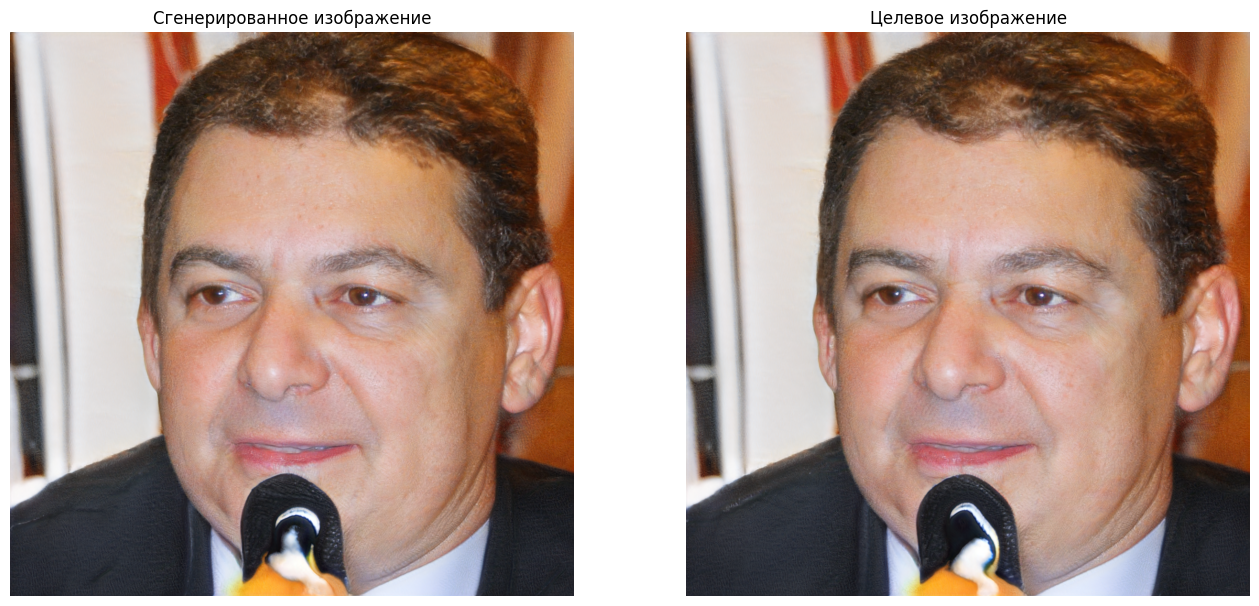

inversion_generated_z/Step [50/200], Loss: 0.6341212391853333


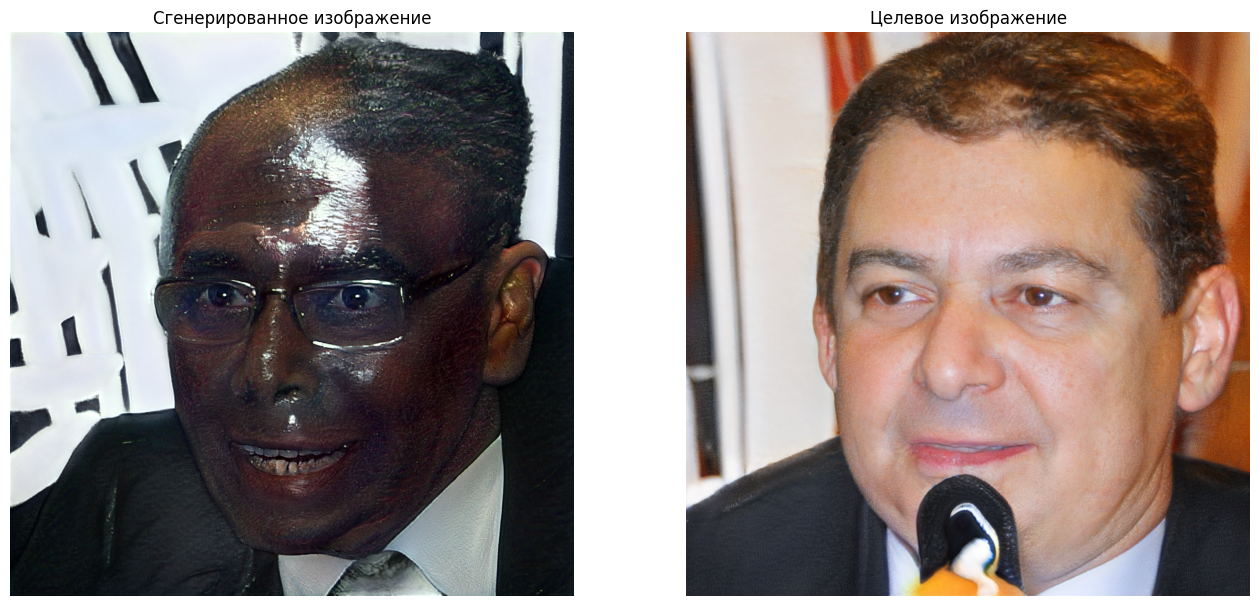

inversion_generated_z/Step [100/200], Loss: 0.6143863797187805


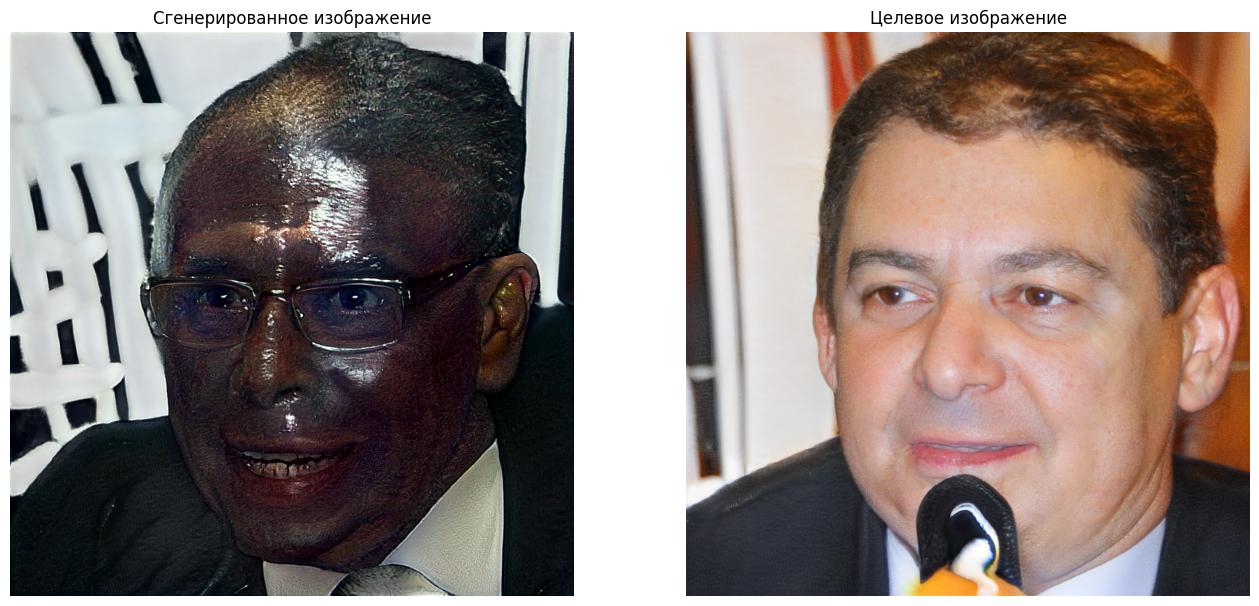

inversion_generated_z/Step [150/200], Loss: 0.6172049641609192


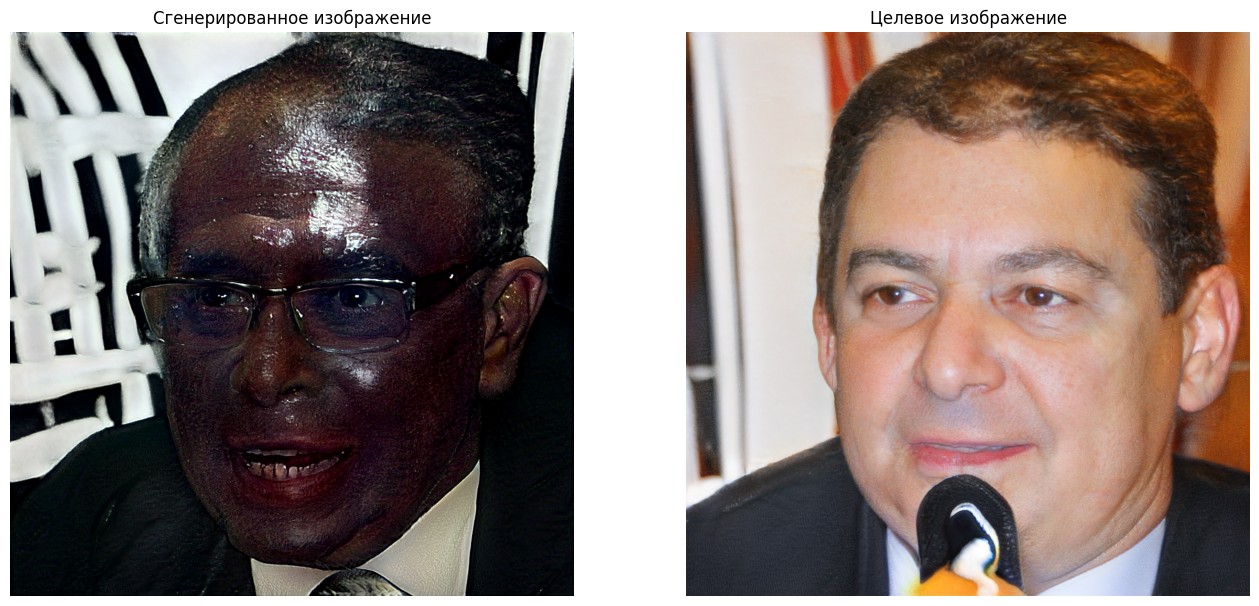

In [21]:
# Оптимизация для редактирования с помощью CLIP

# Создадим оптимизатор Adam
# YOUR CODE IS HERE
optimizer = torch.optim.Adam([latent], lr=0.08)
# А также выберем скедулер
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.99)  # Плавное снижение скорости обучения

num_steps = 200  # количество шагов оптимизации
l2_lambda = 0.008  # коэффициент для L2 регуляризации
id_lambda = 0.001  # коэффициент для identity loss


# Не забудьте сохранять лоссы для дальнейшей визуализации!
losses = {'id': [],
          'l2': [],
          'clip': [],
          'all': []
          }

# Напишем наш цикл оптимизации:
latent_start = latent.detach().clone()
for step in range(num_steps):
    # YOUR CODE IS HERE
    optimizer.zero_grad()

    img_gen, _ = generator([latent], input_is_latent=True, randomize_noise=False)

    clip = clip_loss(img_gen, text_inputs)
    l2 = ((latent - latent_start) ** 2).mean()
    identity = id_loss(img_gen, target_img)

    loss = clip + l2_lambda * l2 + id_lambda * identity

    loss.backward()
    optimizer.step()

    losses['clip'].append(clip.item())
    losses['l2'].append(l2.item())
    losses['id'].append(identity.item())
    losses['all'].append(loss.item())

    # Визуализация и вывод потерь
    if step % 50 == 0:  # Каждые 50 шагов
        print(f"inversion_generated_z/Step [{step}/{num_steps}], Loss: {losses['all'][-1]}")  # Вывод текущих потерь
        fig, axs = plt.subplots(1, 2, figsize=(16, 32))  # Создание подграфиков для визуализации

        # Визуализация сгенерированного изображения
        axs[0].imshow((img_gen.cpu().detach()[0].clip(-1,1).permute(1, 2, 0) + 1) / 2)
        axs[0].set_title("Сгенерированное изображение")  # Заголовок для сгенерированного изображения
        axs[0].axis('off')  # Отключение осей

        # Визуализация целевого изображения
        axs[1].imshow((target_img.cpu().detach()[0].clip(-1,1).permute(1, 2, 0) + 1) / 2)
        axs[1].set_title("Целевое изображение")  # Заголовок для целевого изображения
        axs[1].axis('off')  # Отключение осей
        plt.show()

Визуализируйте лоссы в зависимости от step

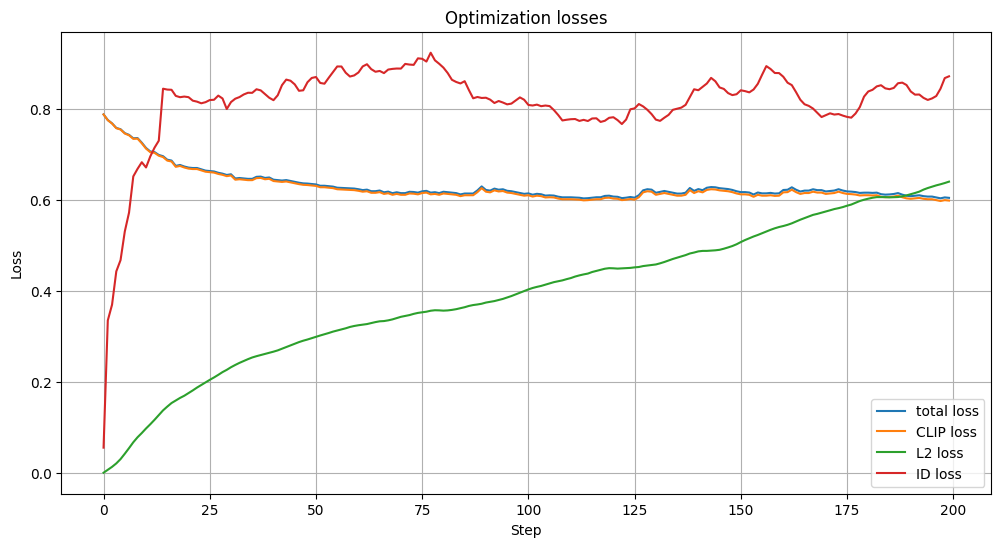

In [22]:
# YOUR CODE IS HERE
import matplotlib.pyplot as plt

steps = range(len(losses["all"]))

plt.figure(figsize=(12, 6))

plt.plot(steps, losses["all"], label="total loss")
plt.plot(steps, losses["clip"], label="CLIP loss")
plt.plot(steps, losses["l2"], label="L2 loss")
plt.plot(steps, losses["id"], label="ID loss")

plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Optimization losses")
plt.legend()
plt.grid(True)
plt.show()

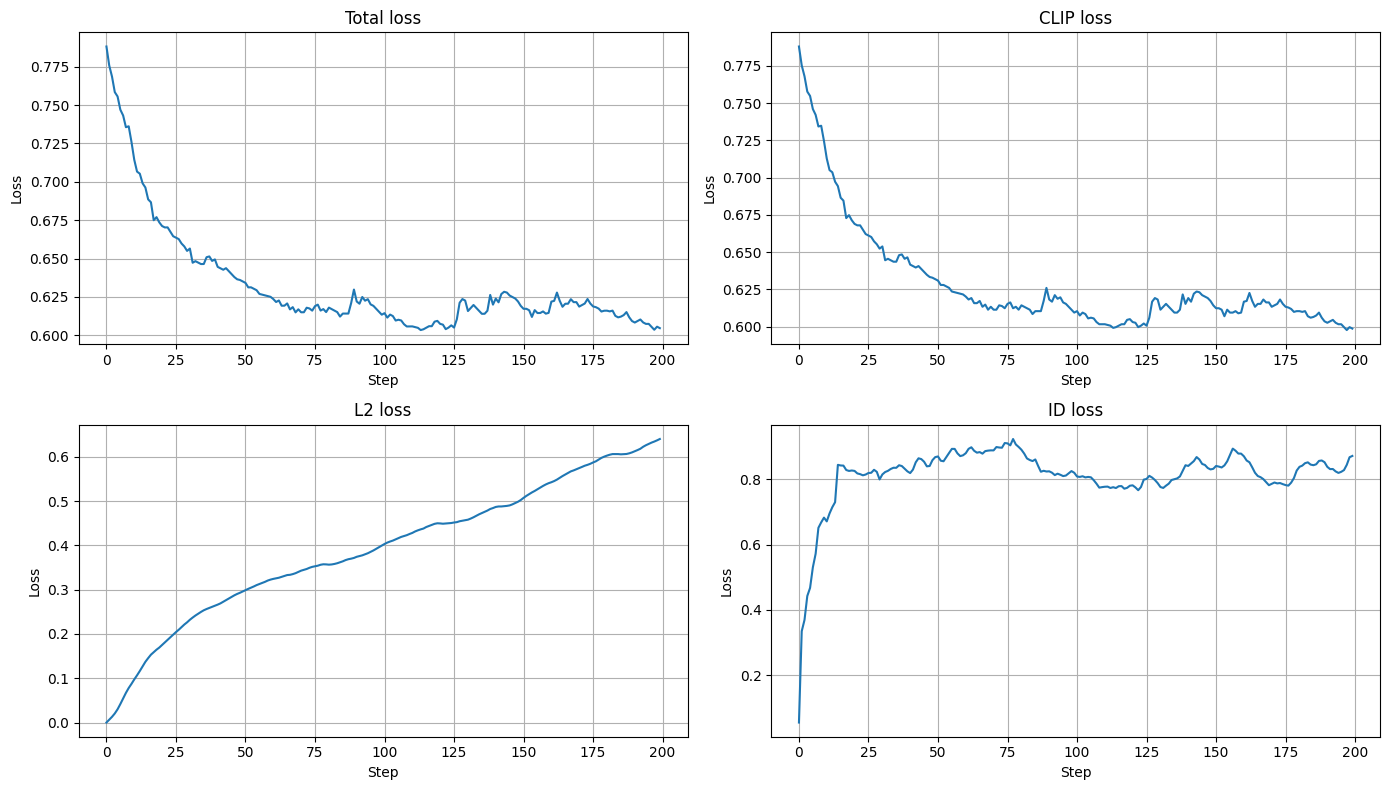

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].plot(losses["all"])
axes[0, 0].set_title("Total loss")

axes[0, 1].plot(losses["clip"])
axes[0, 1].set_title("CLIP loss")

axes[1, 0].plot(losses["l2"])
axes[1, 0].set_title("L2 loss")

axes[1, 1].plot(losses["id"])
axes[1, 1].set_title("ID loss")

for ax in axes.ravel():
    ax.set_xlabel("Step")
    ax.set_ylabel("Loss")
    ax.grid(True)

plt.tight_layout()
plt.show()

/tmp/ipykernel_13233/2850948698.py:5: RuntimeWarning: divide by zero encountered in divide
  values = values / values[0]
/tmp/ipykernel_13233/2850948698.py:5: RuntimeWarning: invalid value encountered in divide
  values = values / values[0]


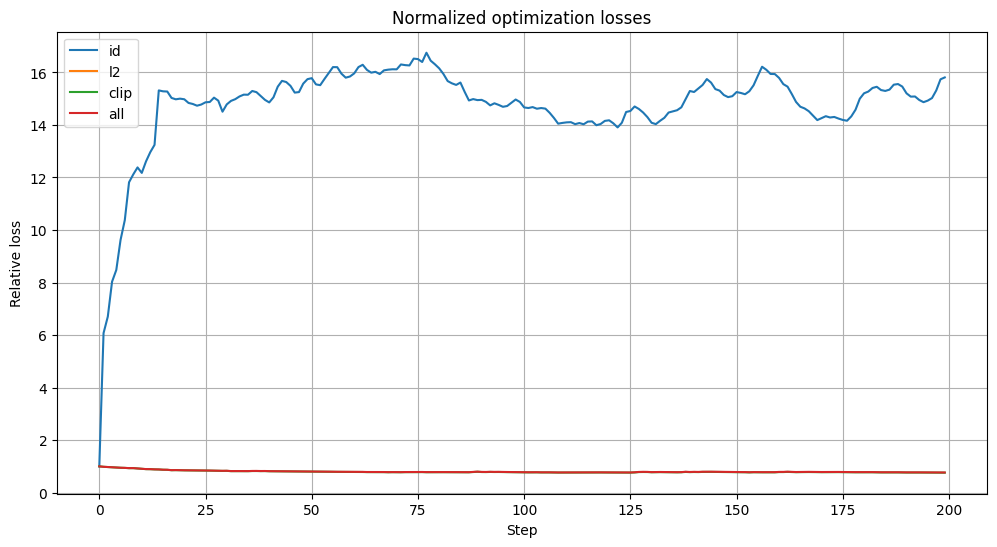

In [25]:
plt.figure(figsize=(12, 6))

for name, values in losses.items():
    values = np.array(values)
    values = values / values[0]
    plt.plot(values, label=name)

plt.xlabel("Step")
plt.ylabel("Relative loss")
plt.title("Normalized optimization losses")
plt.legend()
plt.grid(True)
plt.show()

Сохряним результаты!

In [26]:
import os

filename = prompt

# Save the latents to a .pt file.
latent_path = os.path.join(save_dir, filename + ".pt")
torch.save(latent, latent_path)

# Save the image to a .png file.
image_path = os.path.join(save_dir, filename + ".png")
save_image(img_gen, image_path)


print(f"Ваше изображение и латенты успешно сохранены в папке {save_dir}")

Ваше изображение и латенты успешно сохранены в папке results


### Вывооды

Напишите ваши выводы, что получилось, что нет, почему получилось, почему нет.

* В процессе оптимизации CLIP loss и общий loss постепенно уменьшаются. Это означает, что оптимизация
действительно работает: латентный вектор изменяется так, чтобы сгенерированное изображение становилось
ближе к текстовому запросу.

* L2 loss монотонно растёт. Это ожидаемо: латентный вектор всё дальше уходит от начального значения, потому что модель пытается изменить изображение в сторону текстового описания. L2-регуляризация ограничивает это изменение, но не запрещает его полностью.

* ID loss сильно возрастает в начале и затем колеблется на высоком уровне. Это означает, что при редактировании плохо сохраняется identity исходного человека. Иными словами, модель меняет не только нужный атрибут, но и личность/внешность в целом.

* По графикам видно, что главный вклад в общий loss вносит CLIP loss: кривые total loss и CLIP loss почти совпадают. Это значит, что коэффициенты при L2 и ID loss достаточно маленькие, и они слабо влияют на итоговую оптимизацию. Поэтому модель в первую очередь старается удовлетворить текстовый промпт, а сохранение исходной личности оказывается слабее.

* Что получилось: удалось запустить CLIP-оптимизацию в латентном пространстве StyleGAN и добиться уменьшения CLIP loss. То есть изображение стало лучше соответствовать текстовому описанию с точки зрения CLIP.

* Что получилось хуже: identity сохраняется недостаточно хорошо. Также редактирование может затрагивать не только нужный признак, но и другие свойства изображения: лицо, позу, освещение, фон или общую структуру. Это связано с тем, что в латентном пространстве StyleGAN признаки не полностью независимы друг от друга.

* Почему так произошло: CLIP loss задаёт только семантическое направление изменения, но не гарантирует аккуратное локальное редактирование. Если веса L2 и ID loss малы, оптимизация может сильно сдвигать латентный вектор ради уменьшения CLIP loss. Поэтому изображение становится ближе к текстовому запросу, но может терять похожесть на исходное лицо.

* Для улучшения результата можно увеличить коэффициент identity loss и/или L2 loss, уменьшить learning rate, увеличить число шагов оптимизации, использовать более аккуратный scheduler или оптимизировать не весь latent vector, а только часть слоёв StyleGAN. Также важно проверять результат визуально, потому что уменьшение CLIP loss не всегда означает качественное и реалистичное редактирование.